# EDA : Target and Temporal Analysis

This notebook explores climate risk class distributions, sea surface temperature anomalies (SSTA), seasonality, autocorrelation, and potential lead-time relationships using the TAO dataset.


In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/processed/tao-all2-train.csv")
val = pd.read_csv("../data/processed/tao-all2-val.csv")
test = pd.read_csv("../data/processed/tao-all2-test.csv")

# Run from the repo root whether the kernel starts in notebooks/ (VS Code default) or the root
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

Working directory: c:\Users\sdhar\OneDrive\Desktop\School Documents\BTT\AWS-1A-climate-risk-modeling-for-supply-chain-resiliency


In [2]:
print("Training:", train.shape)
print("Validation:", val.shape)
print("Testing:", test.shape)

print("\n Columns:")
print(train.columns.tolist())

Training: (67892, 30)
Validation: (62620, 30)
Testing: (30561, 30)

 Columns:
['obs', 'year', 'month', 'day', 'latitude', 'longitude', 'zonal_wind', 'meridional_wind', 'humidity', 'air_temp', 'ss_temp', 'standardized_date', 'buoy_segment_id', 'nominal_lat', 'nominal_lon', 'site_id', 'monthly_clim', 'sst_anomaly', 'risk_class', 'temp_lag_30', 'temp_mean_30d', 'temp_std_30d', 'temp_lag_90', 'temp_mean_90d', 'temp_std_90d', 'zonal_wind_scaled', 'meridional_wind_scaled', 'humidity_scaled', 'air_temp_scaled', 'ss_temp_scaled']


In [3]:
print(train["risk_class"].value_counts(dropna=False))

risk_class
Neutral          39209
Moderate Warm    12521
Moderate Cool     9876
Extreme Cool      3601
Extreme Warm      2685
Name: count, dtype: int64


In [4]:
# Comparing risk class distributions across data splits

for name, df in [
    ("Training", train),
    ("Validation", val),
    ("Testing", test)
]:
    print(f"\n{name}:")
    print(
        (df["risk_class"].value_counts(normalize=True, dropna=False) * 100).round(2)
    )


Training:
risk_class
Neutral          57.75
Moderate Warm    18.44
Moderate Cool    14.55
Extreme Cool      5.30
Extreme Warm      3.95
Name: proportion, dtype: float64

Validation:
risk_class
Neutral          40.38
Moderate Cool    21.50
Moderate Warm    15.53
NaN              13.68
Extreme Cool      7.61
Extreme Warm      1.30
Name: proportion, dtype: float64

Testing:
risk_class
Neutral          34.14
Extreme Warm     17.46
Moderate Warm    16.06
NaN              15.69
Moderate Cool    14.49
Extreme Cool      2.16
Name: proportion, dtype: float64


# Missing Target Labels

### Findings
The validation and testing sets contain 8,568 (13.68%) and 4,795 (15.69%) missing risk labels, respectively. These correspond to missing SSTA values caused by unavailable monthly climatology baselines, rather than missing SST observations.

This is consistent with the preprocessing approach, which calculates the historical baselines using training data only to prevent data leakage. However, the missing labels reduce the number of observations available for evaluation.

In [5]:
for name, df in [
    ("Training", train),
    ("Validation", val),
    ("Testing", test)
]:
    print(f"\n {name}:")
    print("Missing risk classes:", df["risk_class"].isna().sum())
    print("Missing SSTA:", df["sst_anomaly"].isna().sum())


 Training:
Missing risk classes: 0
Missing SSTA: 0

 Validation:
Missing risk classes: 8567
Missing SSTA: 8567

 Testing:
Missing risk classes: 4795
Missing SSTA: 4795


In [6]:
for name, df in [
    ("Validation", val),
    ("Testing", test)
]:
    missing = df[df["risk_class"].isna()]

    print(f"\n{name}:")
    print("Missing monthly climatology:",
          missing["monthly_clim"].isna().sum())

    print("Missing SST:", missing["ss_temp"].isna().sum())


Validation:
Missing monthly climatology: 8567
Missing SST: 0

Testing:
Missing monthly climatology: 4795
Missing SST: 0


# Class Distribution Across Data Splits

### Findings
Neutral conditions are the most common across all 3 datasets, although their proportion decreases from 57.75% in training to 40.50% in testing. The validation set contains a higher proportion of cooling anomalies, while Extreme Warm increases **significantly** in testing (3.95% in training, compared to 20.71% in testing). This increase is consistent with the strong 1997-98 El Nino event.

These differences suggest a shift in class distributions over time, which could make it more challenging for the model to predict extreme warming conditions if it hasn't learned enough about them during training. The percentages exclude observations with missing risk labels.

In [7]:
class_order = [
    "Extreme Cool",
    "Moderate Cool",
    "Neutral",
    "Moderate Warm",
    "Extreme Warm"
]

class_distribution = pd.DataFrame({
    "Training": train["risk_class"].value_counts(normalize=True) * 100,
    "Validation": val["risk_class"].value_counts(normalize=True) * 100,
    "Testing": test["risk_class"].value_counts(normalize=True) * 100
}).reindex(class_order)

display(class_distribution.round(2))

,Training,Validation,Testing
risk_class,,,
Extreme Cool,5.30,8.82,2.56
Moderate Cool,14.55,24.91,17.18
Neutral,57.75,46.78,40.50
Moderate Warm,18.44,17.99,19.05
Extreme Warm,3.95,1.50,20.71


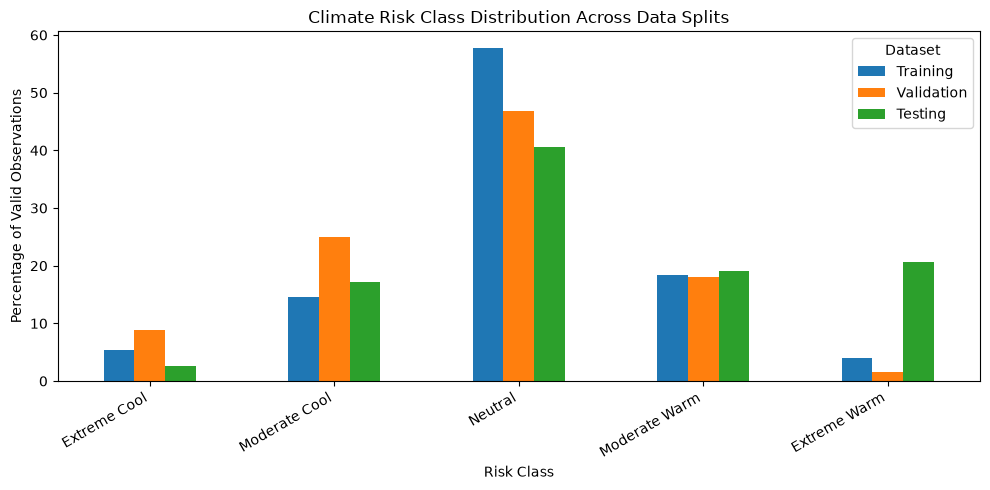

In [8]:
ax = class_distribution.plot(
    kind= "bar",
    figsize=(10,5)
)

plt.title("Climate Risk Class Distribution Across Data Splits")
plt.xlabel("Risk Class")
plt.ylabel("Percentage of Valid Observations")
plt.xticks(rotation= 30, ha="right")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

### Class Distribution by Year
This section examines how climate risk class distributions change over time and whether certain years show higher proportions of warming or cooling anomalies



In [10]:
df_all = pd.concat([train, val, test], ignore_index=True)
print(df_all.shape)

(161073, 30)


In [11]:
# Calculate yearly class distributions
yearly_distribution = pd.crosstab(
    df_all["year"],
    df_all["risk_class"],
    normalize="index"
) * 100

yearly_distribution = yearly_distribution.reindex(
    columns=class_order,
    fill_value=0
)

display(yearly_distribution.round(2))

risk_class,Extreme Cool,Moderate Cool,Neutral,Moderate Warm,Extreme Warm
year,,,,,
1980,13.92,22.15,41.77,11.39,10.76
1981,54.49,22.29,13.00,8.67,1.55
1982,20.19,10.67,17.17,6.26,45.71
1983,23.62,5.25,3.21,2.04,65.89
1984,30.12,41.21,20.89,6.63,1.15
1985,17.09,44.78,33.50,4.12,0.51
1986,2.84,20.08,48.15,24.33,4.60
1987,0.00,5.10,36.77,37.50,20.63
1988,35.35,28.70,28.60,7.34,0.00


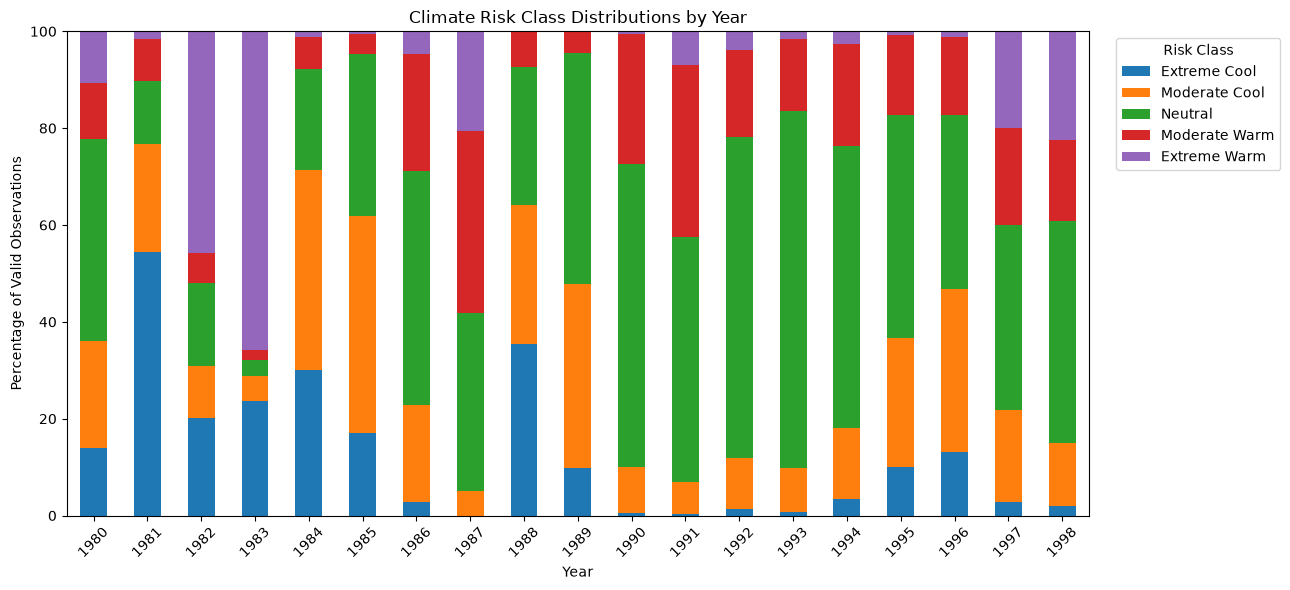

In [12]:
ax = yearly_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(13,6)
)

plt.title("Climate Risk Class Distributions by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Valid Observations")
plt.legend(
    title="Risk Class",
    bbox_to_anchor=(1.02, 1),
    loc = "upper left"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SSTA Sanity Check
This section examines how sea surface temperature anomalies change over time and whether the calculated anomalies align with historical ENSO patterns.

### Findings
Monthly average SSTA values fluctuate above and below zero, indicating periods of warming and cooling relative to the historical baseline. All patterns align with the timing of historical El Nino and La Nina events for 1982-1983 and 1997-1998.

The graph also contains a gap around 198301984, which may indicate missing observations. Since the averages include all available buoy sites, changes in data coverage could influence the results.

Our time-based lag and rolling features should be helpful for these irregularly spaced observations. However, it is something to keep an eye out for.

In [15]:
print(df_all.columns.tolist())

['obs', 'year', 'month', 'day', 'latitude', 'longitude', 'zonal_wind', 'meridional_wind', 'humidity', 'air_temp', 'ss_temp', 'standardized_date', 'buoy_segment_id', 'nominal_lat', 'nominal_lon', 'site_id', 'monthly_clim', 'sst_anomaly', 'risk_class', 'temp_lag_30', 'temp_mean_30d', 'temp_std_30d', 'temp_lag_90', 'temp_mean_90d', 'temp_std_90d', 'zonal_wind_scaled', 'meridional_wind_scaled', 'humidity_scaled', 'air_temp_scaled', 'ss_temp_scaled']


In [16]:
# Summary stats for SST anomalies
display(df_all["sst_anomaly"].describe())

# Check date coverage and available observations
print("Earliest date:", df_all["standardized_date"].min())
print("Latest date:", df_all["standardized_date"].max())
print("Valid SSTA observations:", df_all["sst_anomaly"].notna().sum())

count    147711.000000
mean          0.012066
std           1.050376
min          -6.630000
25%          -0.490000
50%           0.000000
75%           0.480000
max           6.140000
Name: sst_anomaly, dtype: float64

Earliest date: 1980-03-07
Latest date: 1998-06-23
Valid SSTA observations: 147711


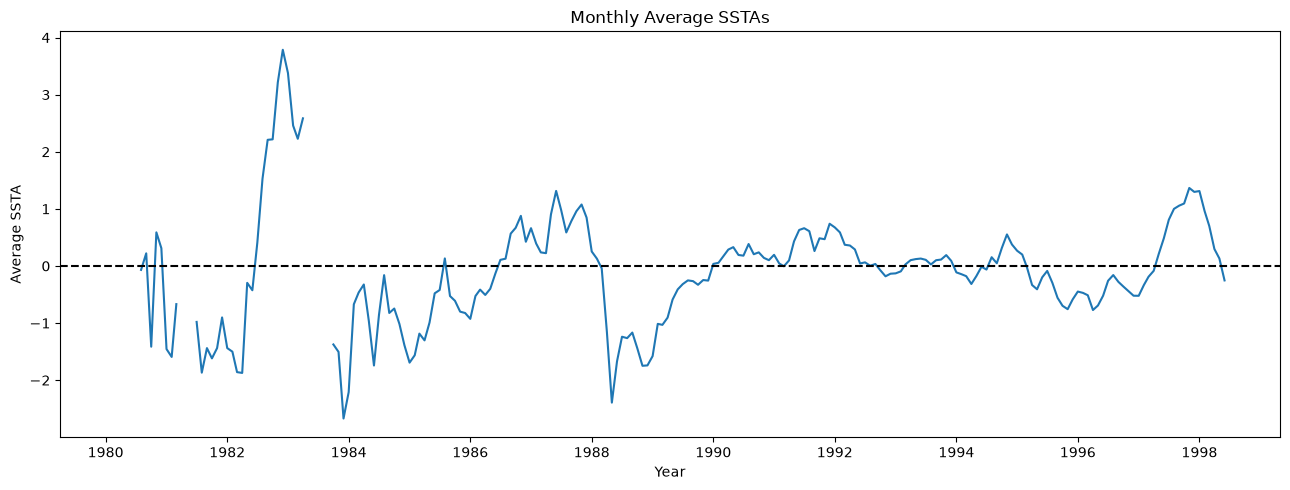

In [17]:
df_all["standardized_date"] = pd.to_datetime(
    df_all["standardized_date"]
)

# Calculating monthly avg SSTA
monthly_ssta = (
    df_all.dropna(subset=["sst_anomaly"])
    .set_index("standardized_date")["sst_anomaly"]
    .resample("MS")
    .mean()
)

plt.figure(figsize=(13,5))
plt.plot(monthly_ssta.index, monthly_ssta.values)

plt.axhline(0, color = "black", linestyle="--")

plt.title("Monthly Average SSTAs")
plt.xlabel("Year")
plt.ylabel("Average SSTA")

plt.tight_layout()
plt.show()

In [18]:
# Finding months w/o valid SSTA observations

missing_months = monthly_ssta[monthly_ssta.isna()]

print("Number of months with missing SSTA averages:", len(missing_months))

display(missing_months)

Number of months with missing SSTA averages: 12


standardized_date
1980-04-01   NaN
1980-05-01   NaN
1980-06-01   NaN
1980-07-01   NaN
1981-04-01   NaN
1981-05-01   NaN
1981-06-01   NaN
1983-05-01   NaN
1983-06-01   NaN
1983-07-01   NaN
1983-08-01   NaN
1983-09-01   NaN
Name: sst_anomaly, dtype: float64

In [20]:
monthly_counts = (
    df_all.set_index("standardized_date")
    .resample("MS")
    .agg(
        total_observations=("ss_temp", "size"),
        valid_ssta=("sst_anomaly", "count")
    )
)

display(monthly_counts.loc["1982":"1985"])

,total_observations,valid_ssta
standardized_date,,
1982-01-01,31,31
1982-02-01,28,28
1982-03-01,31,31
1982-04-01,30,30
1982-05-01,31,31
1982-06-01,30,30
1982-07-01,31,31
1982-08-01,31,31
1982-09-01,30,30


# Seasonality Analysis
This section examines seasonal patterns in SSTs to determine whether calendar-based features may be useful for forecasting.

### Findings
Average SSTs show a clear seasonal pattern, increasing from January through April and May before declining during the following months. A similar pattern appears across the 5 selected buoy sites, although the temperature ranges and timing of seasonal changes by location.

These findings suggest that calendar month and buoy location may be useful predictors. Cyclical month encoding could be explored during feature engineering (if not already done) to help the model capture recurring seasonal patterns.

This is seasonality in **raw**  SST.

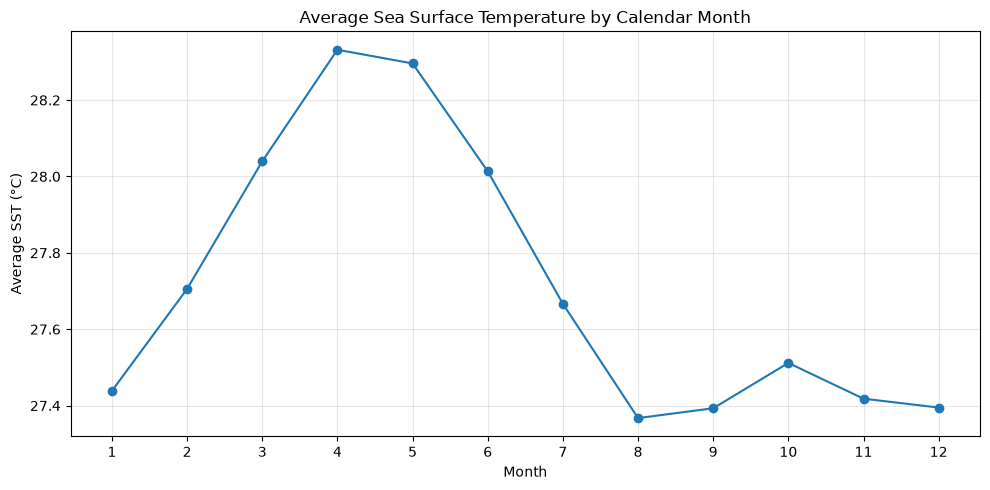

In [21]:
monthly_sst = df_all.groupby("month")["ss_temp"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sst.index, monthly_sst.values, marker="o")

plt.title("Average Sea Surface Temperature by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average SST (°C)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

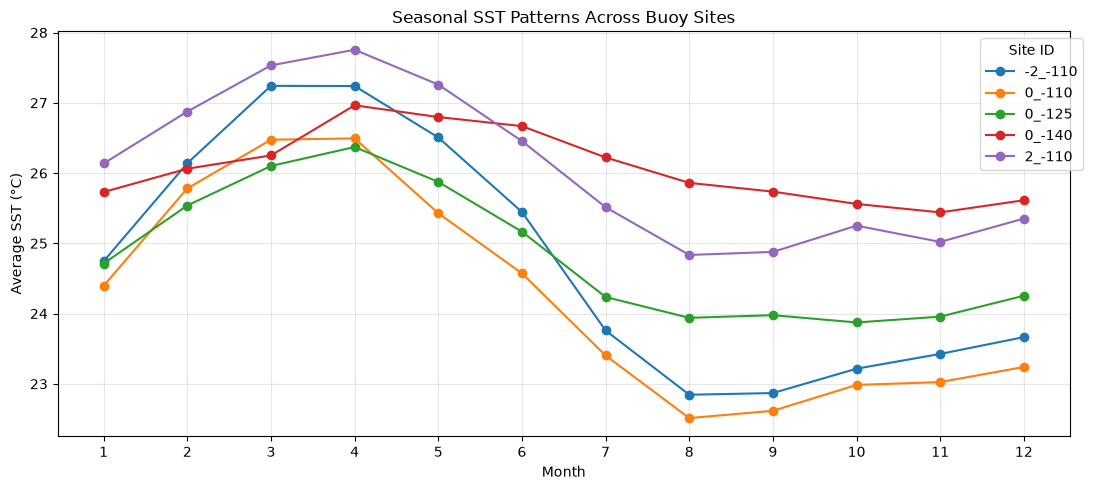

In [22]:
top_sites = (
    df_all.groupby("site_id")["ss_temp"]
    .count()
    .nlargest(5)
    .index
)

# Calculate average SST by month for each selected site
site_seasonality = (
    df_all[df_all["site_id"].isin(top_sites)]
    .groupby(["month", "site_id"])["ss_temp"]
    .mean()
    .unstack()
)

# Plot seasonal patterns
site_seasonality.plot(figsize=(11, 5), marker="o")

plt.title("Seasonal SST Patterns Across Buoy Sites")
plt.xlabel("Month")
plt.ylabel("Average SST (°C)")
plt.xticks(range(1, 13))
plt.legend(title="Site ID", bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Autocorrelation & Lag Feature Analysis
This section examines temporal relationships in SST anomalies and evaluates the potential usefulness of existing lag features.

,Lag (Months),Autocorrelation
0,1,0.901
1,2,0.795
2,3,0.724
3,4,0.630
4,5,0.526
5,6,0.384
6,7,0.242
7,8,0.042
8,9,-0.115
9,10,-0.191


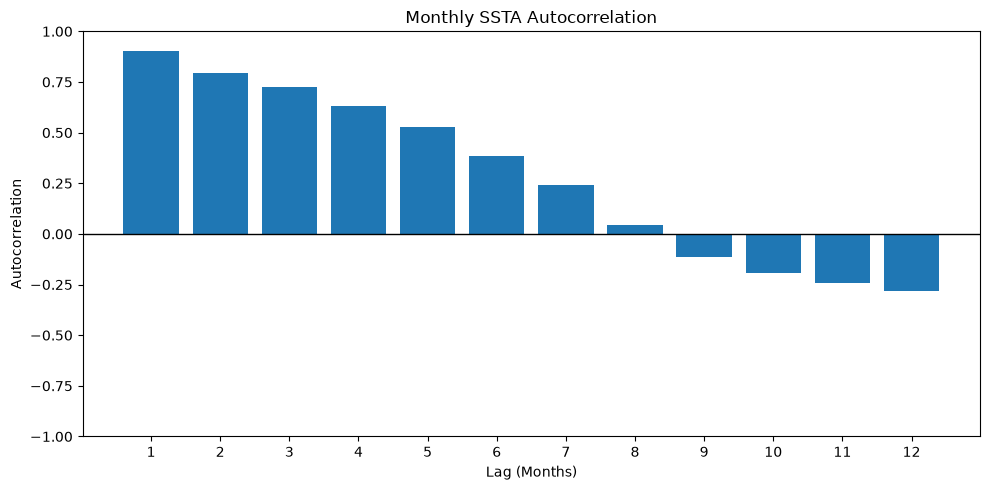

In [23]:
lags = range(1, 13)

acf_results = pd.DataFrame({
    "Lag (Months)": lags,
    "Autocorrelation": [
        monthly_ssta.autocorr(lag=lag)
        for lag in lags
    ]
})

display(acf_results.round(3))

plt.figure(figsize=(10, 5))
plt.bar(
    acf_results["Lag (Months)"],
    acf_results["Autocorrelation"]
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Monthly SSTA Autocorrelation")
plt.xlabel("Lag (Months)")
plt.ylabel("Autocorrelation")
plt.xticks(range(1, 13))
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

In [26]:
features_train = pd.read_csv("data/processed/features-train.csv")

print("Dataset shape:", features_train.shape)
print("\nColumns:")
print(features_train.columns.tolist())

Dataset shape: (1988, 42)

Columns:
['site_id', 'ym', 'year', 'month', 'ssta', 'zonal_wind_anom', 'mer_wind_anom', 'air_temp_anom', 'humidity', 'lat', 'lon', 'month_sin', 'month_cos', 'ssta_change1', 'ssta_change3', 'ssta_lag1', 'ssta_lag2', 'ssta_lag3', 'ssta_lag6', 'zonal_wind_anom_lag1', 'zonal_wind_anom_lag2', 'zonal_wind_anom_lag3', 'zonal_wind_anom_lag6', 'mer_wind_anom_lag1', 'mer_wind_anom_lag2', 'mer_wind_anom_lag3', 'mer_wind_anom_lag6', 'air_temp_anom_lag1', 'air_temp_anom_lag2', 'air_temp_anom_lag3', 'air_temp_anom_lag6', 'ssta_roll3', 'ssta_roll6', 'zonal_wind_anom_roll3', 'zonal_wind_anom_roll6', 'nino34_ssta_roll3', 'basin_ssta', 'basin_zwind_anom', 'nino34_ssta', 'current_risk', 'target_ssta', 'target_risk']
